<div align="center">

# Classification of the Iris Dataset
<br>

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/qci-wdyk/eqc-models-tutorial/blob/main/tutorial06a-classification-iris.ipynb)

</div>

A `QBoostClassifier` object builds $n$ weak classifiers from one of Decision Tree, Gaussian Naive Bayes, Logistic Regression, or Gaussian Process classifiers. Logistic Regression is the default. The number of classifiers, $n$ is determined as 1,2 or 3-combinations of all features. These classifiers are used to build a Hamiltonian whose minima represents an optimal linear combination of the weak classifiers correctly classifying the most records of the training dataset.

In [8]:
try:
    import eqc_models
except ImportError:
    !pip install eqc-models
import sys
import os
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    accuracy_score,
    roc_curve,
    auc
)
import warnings
warnings.filterwarnings("ignore")

from eqc_models.ml.classifierqboost import QBoostClassifier
try:
    from google.colab import userdata
except ImportError:
    userdata = None

In [9]:
# Define the API URL and token  for QCI
if userdata is None:
    api_token = "Z!tG1IEyIVI9ZG*HLZrdBMB6JHax5TX=**^Bfy#pCfpsG1=z" # replace or use environment variables to configure
    api_url = "https://api.qci-prod.com"
else:
    api_token = userdata.get("QCI_TOKEN")
    api_url = userdata.get("QCI_API_URL")
    os.environ["QCI_TOKEN"] = api_token
    os.environ["QCI_API_URL"] = api_url

In [10]:
# Set parameters
TEST_SIZE = 0.2

# Read dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [11]:
# Pre-Process
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

for i in range(len(y)):
    if y[i] == 0:
        y[i] = -1
    elif y[i] == 2:
        y[i] = 1

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=42,
)
print("\nTraining Data")
print("="*40)
print(Counter(y_train))
print(X_train.shape)
print(y_train.shape)
print("\nTest Data")
print("="*40)
print(Counter(y_test))
print(X_test.shape)
print(y_test.shape)



Training Data
Counter({np.int64(1): 80, np.int64(-1): 40})
(120, 4)
(120,)

Test Data
Counter({np.int64(1): 20, np.int64(-1): 10})
(30, 4)
(30,)


In [12]:
# Get QBoost model
obj = QBoostClassifier(
    relaxation_schedule=1,
    num_samples=1,
    lambda_coef=0.0,
    weak_cls_strategy='sequential'
)
obj.api_url = api_url
obj.api_token = api_token

# Train
obj.fit(X_train, y_train)

y_train_prd = obj.predict(X_train)
y_test_prd = obj.predict(X_test)


Runtime of _build_weak_classifiers_sq: 0.01 seconds!
Built 4 weak classifiers!
Runtime of get_hamiltonian: 0.02 seconds!
2026-09-03 13:26:14 - Dirac allocation balance = 0 s (unmetered)
2026-09-03 13:26:14 - Job submitted: job_id='6a99adb708442f441bbb6ce8'
2026-09-03 13:26:14 - QUEUED
2026-09-03 13:26:17 - COMPLETED
2026-09-03 13:26:19 - Dirac allocation balance = 0 s (unmetered)
SolutionResults(solutions=array([[4.000000e-07, 0.000000e+00, 5.321283e-01, 4.678713e-01]]), energies=array([-120.0000153]), counts=array([1]), objectives=None, run_time=[179062501], preprocessing_time=19738488, postprocessing_time=[0], penalties=None, device='dirac-3_normalized_qudit', raw_solutions=None, time_units='ns', response={'job_info': {'job_id': '6a99adb708442f441bbb6ce8', 'job_submission': {'problem_config': {'normalized_qudit_hamiltonian_optimization': {'polynomial_file_id': '6a99adb6ff2f309fb9d1bb71'}}, 'device_config': {'dirac-3_normalized_qudit': {'num_samples': 1, 'relaxation_schedule': 1, 'sum

Counter({np.float32(1.0): 80, np.float32(-1.0): 40})
Counter({np.float32(1.0): 20, np.float32(-1.0): 10})
Train precision: 1.0
Train recall: 1.0
Train accuracy: 1.0
Train confusion matrix:
[[40  0]
 [ 0 80]]
Test precision: 1.0
Test recall: 1.0


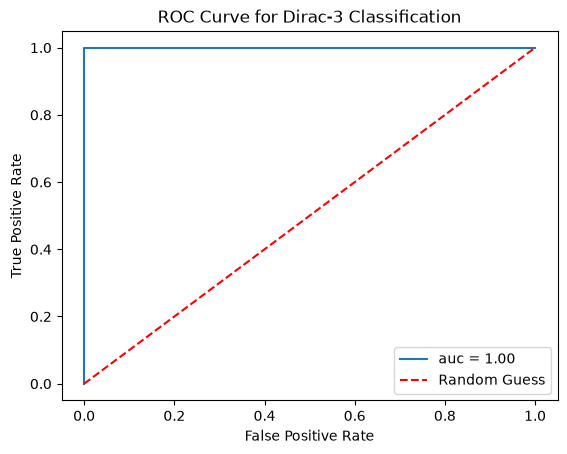

In [13]:
print(Counter(y_train_prd))
print(Counter(y_test_prd))

print(
    "Train precision:",
    precision_score(y_train, y_train_prd, labels=[-1, 1], pos_label=1),
)
print(
    "Train recall:",
    recall_score(y_train, y_train_prd, labels=[-1, 1], pos_label=1),
)
print(
    "Train accuracy:",
    accuracy_score(y_train, y_train_prd),
)
print(
    "Train confusion matrix:",
)
print(
    confusion_matrix(y_train, y_train_prd, labels=[-1, 1]),
)

print(
    "Test precision:",
    precision_score(y_test, y_test_prd, labels=[-1, 1], pos_label=1),
)
print(
    "Test recall:",
    recall_score(y_test, y_test_prd, labels=[-1, 1], pos_label=1),
)
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_test_prd)
area = auc(false_positive_rate, true_positive_rate)
plt.plot(false_positive_rate, true_positive_rate, label=f'auc = {area:.2f}')
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Dirac-3 Classification')
plt.legend()